In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

In [2]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP Current Module',
    #'ESP Vibration X',
    #'ESP Vibration Y',
    'ESP Vibration Module'
    #'ESP Power',
    #"Well_down"
    ]

/tmp/ipykernel_222380/2671570974.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [3]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = totalData["Well Run"].unique()

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

In [29]:
n = 2

gmmTotal = li.GaussianMixtureFit(totalData[Headers].loc[totalData["Well_down"]==0],n,seed=mainSeed)

modelFull = hmm.GMMHMM(
    n_components=2,
    n_mix = 2,
    random_state=mainSeed,
    covariance_type="full",
    #params="st",
    init_params="st",
    algorithm="map"
    )

# modelFull.means_ = gmmTotal.means_
# modelFull.covars__ = gmmTotal.covariances_


modelFull = li.HMMTrainer(X_train[Headers],trainLength,modelFull)

li.PostProcessing(modelFull, totalData, modelData, Headers, "Full States", totalLength)
print(modelFull.get_stationary_distribution())
totalData["Full States"] = totalData["Full States"].map(li.StateConversion(modelFull.get_stationary_distribution(),n))



GMM AIC: 18016460.175991148
GMM BIC: 18017986.30776254
AIC: 15257055.658436082 BIC: 15260131.221700571
[0.73585412 0.26414588]


In [17]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

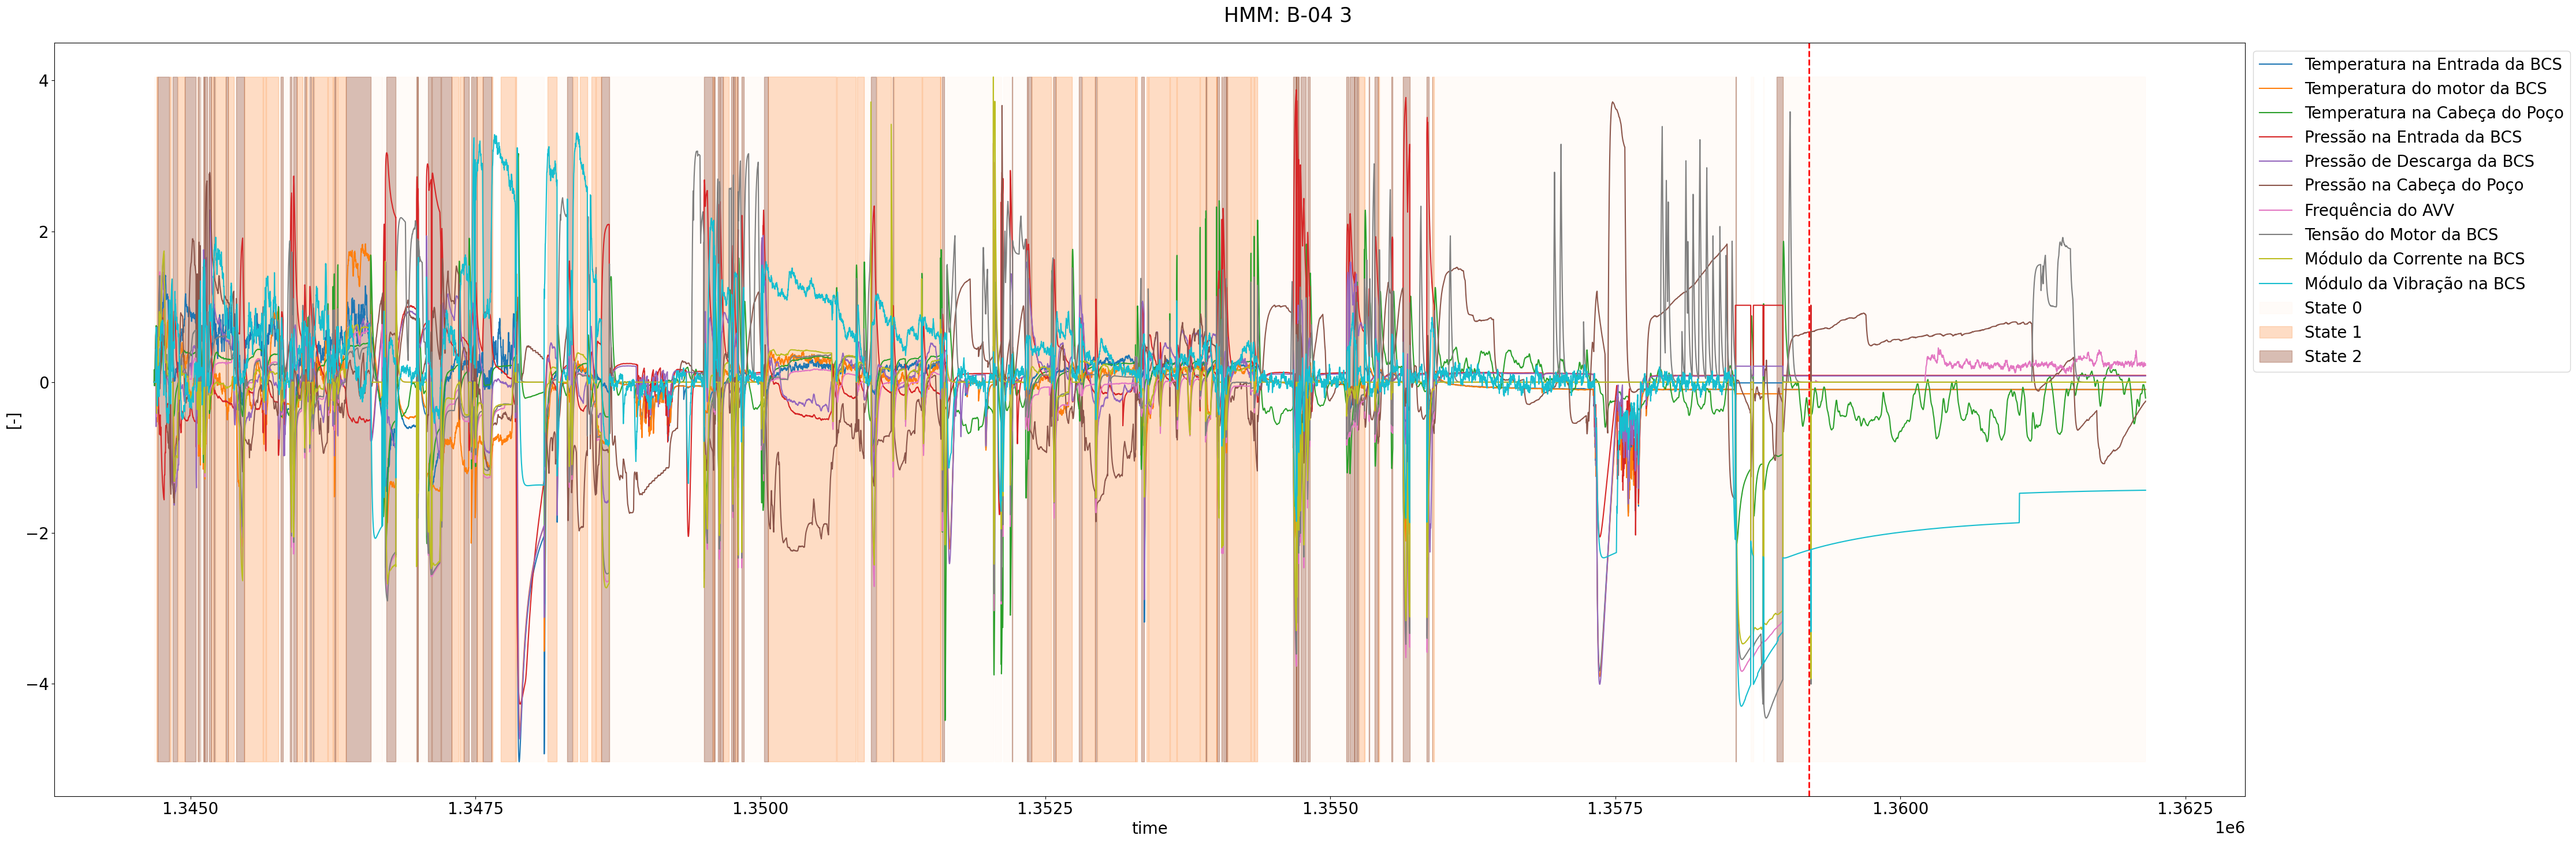

In [ ]:
pump = pumpList[56]
pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="Full States", numberOfStates=n, figsize=(45,15))
plt.rcParams["font.size"]=20

#fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


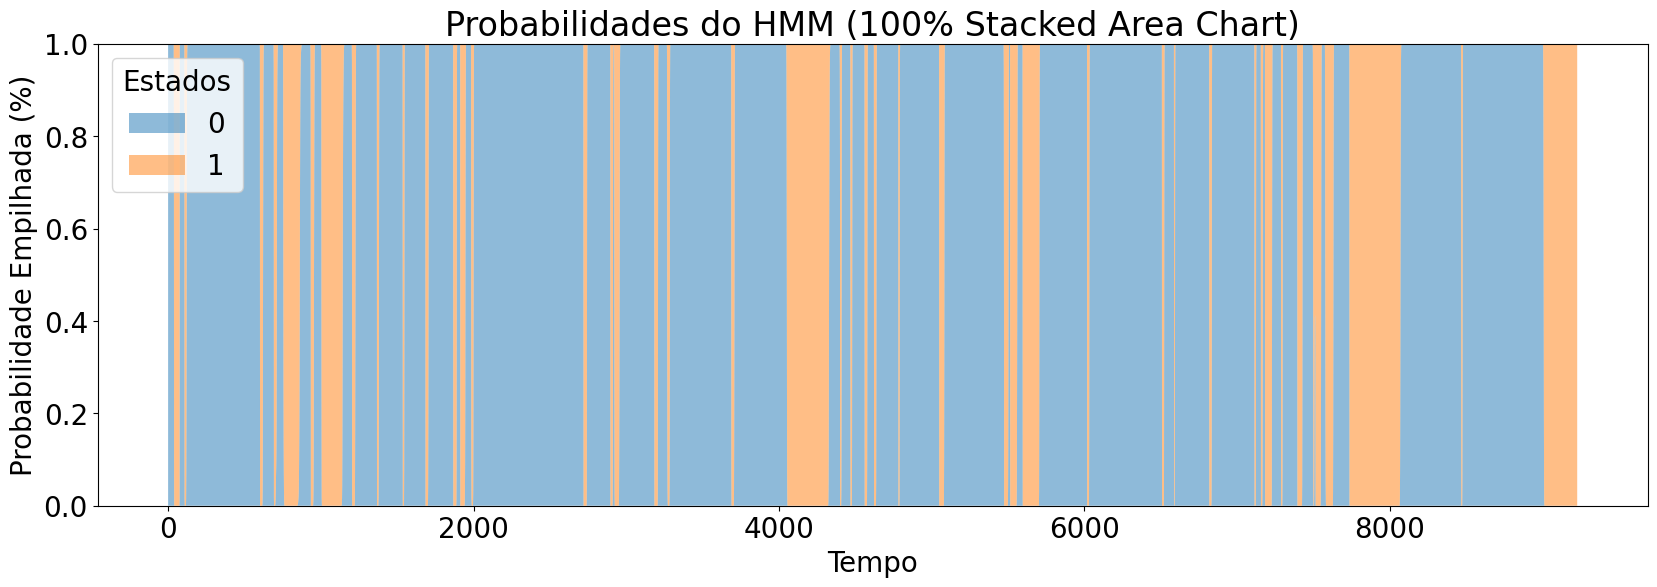

In [11]:
li.PlotHMMProbs(totalData[Headers].loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[0])],modelFull)

In [27]:
modelFull.transmat_

array([[9.99888640e-01, 1.11359687e-04],
       [2.79083537e-03, 9.97209165e-01]])

<Axes: >

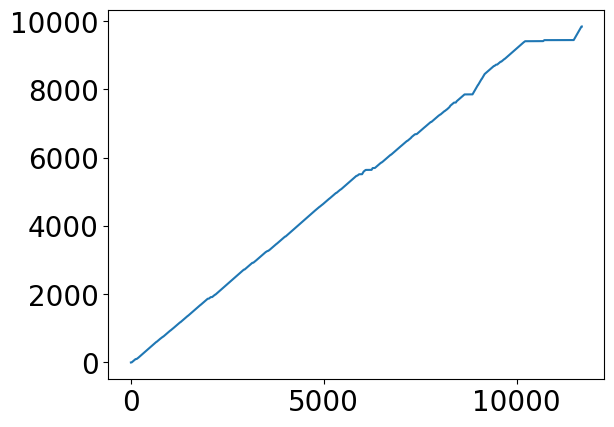

In [28]:
pumpData["Full States"].cumsum().plot()